# Linear least squares fit

Solve the tasks below.
For each task, give reasons for your solution by commenting in the notebook.
In conclusion, summarize your findings and contextualize them. What have you learned? Do the results make sense?

Your results will be examined for plagiarism. Please use your own plot styles, articulate your own thoughts, and present your own experimental approaches.

## Tasks

Perform a least squares fit of a parabola of third order

$$ y(x) = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 $$

for the thirteen independent measurments $(x_i, y_i)$ given by $(-1.5, -8.0 \pm 2.5)$, $(-1.25, -2.5 \pm 2.0)$, $(-1.0, -1.5 \pm 1.5)$, $(-0.75, 1.0 \pm 1.0)$, $(-0.5, 4.0 \pm 1.0)$, $(-0.25, 4.0 \pm 0.5)$, $(0.0, 5.5 \pm 0.5)$, $(0.25, 4.5 \pm 0.5)$, $(0.5, 5.5 \pm 0.5)$, $(0.75, 3.0 \pm 1.0)$, $(1.0, 3.0 \pm 1.0)$, $(1.25, 4.5 \pm 1.5)$, $(1.5, 7.0 \pm 2.0)$. 

a) Determine the best fit parameters $\hat \theta_i$ and their covariances using the formula for linear least squares fits.

b) Determine the $\chi_\mathrm{obs}^2$ for the best fit parameter. What is the number of degrees of freedom? Plot the $\chi^2$ distribution and indicate $\chi_\mathrm{obs}^2$ in this plot (e.g. by drawing a line at this value).
What is the $p$-value for this fit?

c) Plot the fitted parabola and the $1\sigma$ error band around it as obtaind from the error propagation formula $\sigma_y^2 = A^\mathrm{T} U A$. What is the predicted value $y$ at $x=1$ and its uncertainty?

d) Compare the fit result and the covariance matrix with the results obtained with iminuit. Do the results agree?

e) Plot the data with a straight-line fit. Determine the $p$-value for this straight-line fit. Is this an acceptable description of the data?

f) How does the $p$-value for a straight-line fit change if the error bars are twice as high in this example? Would you say the fit is describing the data well in this case?


### Hints

1) The following numpy functions might come in very handy
* diagonal matrix from vector v in numpy: *A = np.diagflat(v)*
* matrix from column vectors v0, v1, v2, v3: *A = np.column_stack((v0, v1, v2, v3))*
* multiplication of matrices A and B in numpy: *C = A.dot(B)*
* transposed matrix: *A_T = np.transpose(A)*
* inverse matrix: *A_inv = inv(A)*, this requires *from numpy.linalg import inv*

2) It might be useful to write a function which returns the uncertainty $\sigma_y$ for a numpy array of $x$ values. A function $f$ that only works for a scalar value $x$ can be vectorized (i.e., it works also for numpy arrays) with *numpy.vectorize*.

3) Data points with error bars can be drawn with *plt.errorbar(x, y, yerr=sigma_y)*

4) A band between $y$ values can be drawn with the aid of *matplotlib.pyplot.fill_between*

## Comments on Python's `iminuit`

The KIP service has iminuit version 1.3.8. Please note that the most recent version is $\geq2.0.0$ and that the [documentation](https://iminuit.readthedocs.io/en/stable/) applies to *that* version. Some backward-incompatible changes have been introduced, some of which changed some interfaces. For your tasks that mainly affects the `minuit.Minuit` constructor. The following shows the construction of a `Minuit` object for version 1.3.8 (in case you use the KIP service or a version $<2.0.0$) and $\geq2.0.0$ (in case you use another service implementing a higher version), respectively.
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=1
# likelihood method: errordef=0.5
m = Minuit(func, par1=0.1, par2=0.1, ..., parN=0.1, errordef=1)
```

And this would be the equivalent workflow for versions >2.0.0
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=Minuit.LEAST_SQUARES
# likelihood method: errordef=Minuit.LIKELIHOOD

# add errordef as an attribute of your defined minimisation function which will be checked for when optimised
func.errordef = Minuit.LEAST_SQUARES
m = Minuit(func, par1=0.1 par2=0.1, ..., parN=0.1)
```

Another (potenitally) Jupiter related *feature* is the fact that `m.migrad()`, `m.matrix()`, `m.minos()` etc. can yield a nice summary of the respective procedure. However, in order to show it, either of these methods (and potentially others in case you use them) have to be *the last line of a code cell*. If there is *anything* coming afterwards, the output will not be printed, hence, for anything that follows, it is recommended to start a new code cell.


## Solutions

### Finding best fit parameters
a) Determine the best fit parameters $\hat \theta_i$ and their covariances using the formula for linear least squares fits.

Note that in the following explanation, superscript numbers always mean exponents, not indices.

We want to fit $ f(x) = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 $ to our data.

This kind of polynomial function is linear in its parameters (coefficients), meaning an exact solution exists.

$$ f(x ; \vec{\theta}) = \sum \limits _{k = 0}^{3} x^{k} \cdot \theta_k $$

For a set of inputs $\vec{x}$, our model predicts outputs: $ \vec{\mu} = \bold{A} \vec{\theta} $, with $ A_{ij} = x_i^j$.

This lets the sum of the square residuals ($\chi^2$) be calculated in the following way. After taking the gradient of this expression and setting to zero, matrix algebra finds us the $\vec{\theta}$ which minimizes the square residuals.

$$ \chi^2 = (\vec{y} - \bold{A}\vec{\theta})^\mathsf{T} \bold{C}^{-1} (\vec{y} - \bold{A}\vec{\theta}) \\
\vec{\theta} = (\bold{A}^\mathsf{T} \bold{C}^{-1} \bold{A})^{-1} \bold{A}^\mathsf{T} \bold{C}^{-1} \vec{y} \\
\vec{\theta} = \bold{G} \vec{y} $$

$\bold{C}$ is the matrix representing the covariances of $\vec{y}$. To find the covariances $\bold{C}_\theta $ of our fit parameters, we transform this matrix. Terms cancel again to obtain a simplified result.

$$ \bold{C}_\theta = \bold{G} \bold{C} \bold{G}^\mathsf{T} \\
\bold{C}_\theta = (\bold{A}^\mathsf{T} \bold{C}^{-1} \bold{A})^{-1} $$

Translating these matrix operations into code gives an analytic solution for the least squares regression.

<!-- 
We define a function to calculate the sum of the square differences (weighted by the error) between two data sets. Then we define a polynomial function with free coefficients (our model parameters $\hat \theta_i$). Combining these, we get a function which takes the $\hat \theta_i$ as inputs and calculates the sum of the square residuals ($\chi^2$) between the given data set and the current prediction.

This final function is then minimized using `iminuit` and its `Minuit` method, producing a clean summary table of the optimized parameters as well as their errors, given in the form of the Hesse/covariance matrix. Below this the values from the fit are read out manually as a demonstration. -->

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
from iminuit import Minuit

In [2]:
# data
x = np.array([-1.5,-1.25, -1., -0.75, -0.5, -0.25, 0., 0.25, 0.5, 0.75, 1.0, 1.25, 1.5])
y = np.array([-8, -2.5, -1.5, 1., 4.0, 4., 5.5, 4.5, 3.5, 3., 3., 4.5, 7.])
sigma_y = np.array([2.5, 2., 1.5, 1, 1, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 1.5, 2.])

In [3]:
# put a minus or a space in front of a float
def minus_pad(num: float) -> str:
    if num < 0:
        return str(num)
    return ' ' + str(num)

# nicely print fit parameters with their errors
def print_params(params, params_error, decimal_figs: int = 6) -> None:
    print('===== Fit Parameters =====')
    for i, [theta, theta_error] in enumerate(zip(params, params_error)):
        print(f'theta_{i}: {minus_pad(np.round(theta, decimal_figs))} ± {np.round(theta_error, decimal_figs)}')

A_matrix = x[:, None] ** np.array([0,1,2,3])
C_matrix = np.diag(sigma_y)

params = inv(A_matrix.T @ inv(C_matrix) @ A_matrix) @ A_matrix.T @ inv(C_matrix) @ y[:, None]
cov = inv(A_matrix.T @ inv(C_matrix) @ A_matrix)

params = params.flatten()
params_error = np.sqrt(np.diag(cov))
params_cov = cov

print_params(params, np.sqrt(np.diag(cov)))
print('\n===== Covariance Matrix =====')
print(cov, '\n')

===== Fit Parameters =====
theta_0:  4.370238 ± 0.338102
theta_1: -0.364315 ± 0.752437
theta_2: -2.554223 ± 0.412668
theta_3:  2.326805 ± 0.507292

===== Covariance Matrix =====
[[ 0.11431293 -0.02612766 -0.08788484  0.0163449 ]
 [-0.02612766  0.56616159  0.01106381 -0.33374944]
 [-0.08788484  0.01106381  0.17029452 -0.01723541]
 [ 0.0163449  -0.33374944 -0.01723541  0.25734475]] 



### $\chi^2$ Analysis
b) Determine the $\chi_\mathrm{obs}^2$ for the best fit parameter. What is the number of degrees of freedom? Plot the $\chi^2$ distribution and indicate $\chi_\mathrm{obs}^2$ in this plot (e.g. by drawing a line at this value).
What is the $p$-value for this fit?

The number of degrees of freedom is the total number of data points minus the number of fit parameters. This number is important because it takes into account how complicated the model is. If a model has as many parameters as there are data points, obviously the data is matched perfectly. This is an extreme overfit though. Really we are looking for models which are very good models for the data even with much fewer parameters than data points. In this case:
\begin{gather*}
    \text{Data Points: } 13 \\
    \text{Parameters: } 4 \\
    \text{Degrees of Freedom: } 9
\end{gather*}

To find $\chi^2_{\mathrm{obs}}$, we define a function to calculate the sum of the square differences (weighted by the error) between two data sets. Then we define a `Polynomial` class with free coefficients (our model parameters $\hat \theta_i$). Combining these, we get a final function `chi_square_for_params()` which takes the $\hat \theta_i$ as inputs and calculates the sum of the square residuals ($\chi^2$) between the given data set and the current prediction.

Below, $\chi^2_{\mathrm{obs}}$ is calculated to be about $10.5$, leading to a $p$-value of about $0.310$.

After this we plot the $\chi^2$-distribution for this number of degrees of freedom. This lets us compare the test statistic of our fit with the expected distribution.

This value gives the probability of obtaining a $\chi^2$-Value equal to or more extreme (larger) than this one, under the assumption that the determined parameters are the true values. Often, hypothesis testing is done with significance levels of $p > 0.05$. Because our $p$-value is much larger than any reasonable significance level, we *fail* to reject the null hypothesis.

This leaves us with fairly high confidence that our fit parameters are quite close to the true values.

In [4]:
# takes two data sets and sums their square differences, weighted by an error
def sum_square_residuals(
        data1: np.ndarray | float,
        data2: np.ndarray | float,
        data1_err: np.ndarray | float) -> float:
    square_residuals = (data1 - data2)**2/data1_err**2
    return np.sum(square_residuals)

# define a polynomial function with string representation and jacobian
class Polynomial:
    def __init__(self, params: list | np.ndarray) -> None:
        self.params = params
        self.degree = len(self.params)-1
        self.powers = np.arange(self.degree+1)
    def eval(self, x):
        x = np.atleast_1d(x)
        matr = np.vstack([x]*(self.degree+1))
        matr = matr **self.powers[:,None]
        return self.params @ matr
    def __str__(self) -> str:
        FIGS = 3
        string = str(round(self.params[0], FIGS))
        for i, param in enumerate(self.params[1:]):
            string += f' + {round(self.params[i+1], FIGS)}*x^{i+1}'
        return string
    def jacobian(self, x: np.ndarray | list | float) -> np.ndarray:
        x = np.atleast_1d(x)
        return x[:, None] **self.powers

# calculates chi2_obs of a Polynomial for given parameters
def chi_square_for_params(*args):
    fitcurve = Polynomial([*args])
    data2 = fitcurve.eval(x)
    return sum_square_residuals(y, data2, sigma_y)

degrees_of_freedom = 9
chi2_obs = 10.52692
p-value = 0.30953


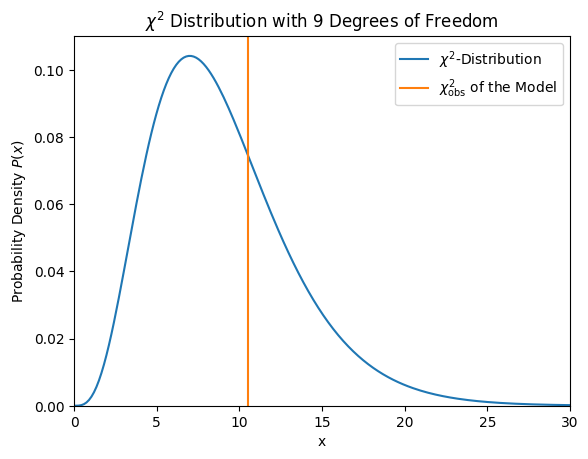

In [5]:
from scipy.stats import chi2
# create function to run and plot goodness of fit tests
def GOF_analysis(chi2_obs, degrees_of_freedom: int, graph_axis_limits, p_sig_figs: int) -> None:
    CHI2_OBS_DEC_FIGS = 5
    # .sf = 'survival function' = 1 - .cdf  (scipy cdfs always integrate from left)
    p_value = chi2.sf(chi2_obs, df = degrees_of_freedom)

    print(f'{degrees_of_freedom = }')
    print(f'chi2_obs = {round(chi2_obs, CHI2_OBS_DEC_FIGS)}')
    print(f'p-value = {np.round(p_value, p_sig_figs)}')

    grid = np.linspace(graph_axis_limits[0][0], graph_axis_limits[0][1], 200)
    plt.plot(grid, chi2.pdf(grid, df = degrees_of_freedom), label = '$\\chi^2$-Distribution')
    plt.axvline(chi2_obs, color = 'tab:orange', label = '$\\chi^2_{\\mathrm{obs}}$ of the Model')
    plt.xlim(graph_axis_limits[0])
    plt.ylim(graph_axis_limits[1])
    plt.xlabel('x')
    plt.ylabel('Probability Density $P(x)$')
    plt.title(f'$\\chi^2$ Distribution with {degrees_of_freedom} Degrees of Freedom')
    plt.legend(loc = 'best')

degrees_of_freedom = len(x) - len(params)
chi2_obs = chi_square_for_params(*params)
GOF_analysis(chi2_obs, degrees_of_freedom, ((0,30), (0,0.11)), 5)

### Plotting the Calculated Curve
c) Plot the fitted parabola and the $1\sigma$ error band around it as obtained from the error propagation formula $\sigma_y^2 = A^\mathrm{T} U A$. What is the predicted value $y$ at $x=1$ and its uncertainty?

We input the parameters which were previously calculated. Then using the mentioned formula we can propagate the error in our parameters $\vec{\theta}$ to obtain an upper and lower bound ($1\sigma_y$ above and below the predicted value) for our model.

Evaluating this explicitly at $x = 1$ gives: $y = 3.78 ± 0.48$ (see below).

Sample prediction for x = 1:
y = 3.78 ± 0.48


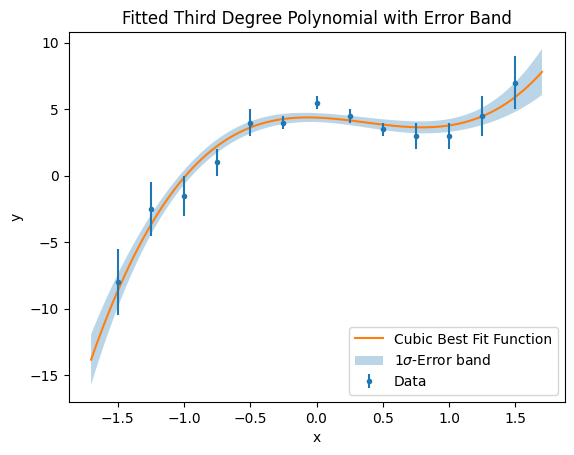

In [ ]:
# define fitcurve with found parameters
cubic_fit = Polynomial(params)

# define a function to plot the polynomial alongside the data and a 1-sigma error band
def plot_fitcurve_with_errorband(
        x, y, sigma_y,
        fitcurve: Polynomial, cov,
        fitcurve_name: str,
        only_curve: bool = False
    ) -> None:
    # define points and evaluate model at them
    grid = np.linspace(-1.7, 1.7, 200)
    y_prediction = fitcurve.eval(grid)

    if only_curve:
        # plot model curve
        plt.plot(grid, y_prediction, label = fitcurve_name)
        plt.legend(loc = 'lower right')
        return
    
    # plot model curve
    plt.plot(grid, y_prediction, label = fitcurve_name, color = 'tab:orange')

    # propagate errors for those points
    J = fitcurve.jacobian(grid)
    sigma = np.sqrt(np.diag(J @ cov @ J.T))
    # create 1-sigma error band
    lower = y_prediction - sigma
    upper = y_prediction + sigma

    # plot data, model, error band
    plt.errorbar(x, y, yerr = sigma_y, linestyle='', marker='.', label = 'Data', color = 'tab:blue')
    plt.fill_between(grid, lower, upper, alpha = 0.3, label = '1$\\sigma$-Error band')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend(loc = 'lower right')
    return

# calculate the model prediction with error at a sample point
sample_x = 1
sample_y = cubic_fit.eval(1)[0]
J = cubic_fit.jacobian(sample_x)
sigma = np.sqrt(np.diag(J @ cov @ J.T))[0]

print(f'Sample prediction for x = {sample_x}:')
print(f'y = {round(sample_y, 2)} ± {round(sigma, 2)}')

plot_fitcurve_with_errorband(
    x, y, sigma_y,
    cubic_fit, cov, 'Cubic Best Fit Function'
    )
plt.title('Fitted Third Degree Polynomial with Error Band');

### Comparing to `iminuit`
d) Compare the fit result and the covariance matrix with the results obtained with iminuit. Do the results agree?

Now we use the same square residuals test statistic ($\chi^2$) from before. We use the `iminuit` module to minimize the $\chi^2$ function with respect to the parameters $\vec{\theta}$.

The `minigrad()` method finds and nicely presents the fit parameters which minimize $\chi^2$ along with their covariance matrix.

A visual inspection shows that the fit parameters from this method are relatively similar to the previous ones from the analytical approach. They all match to at least one digit. Seeing the graphs of the two models overlaid on top of each other also shows that the models generally agree with each other.

In [7]:
# use iminuit to find and show the parameters which minimise the input function
m = Minuit(chi_square_for_params, *[1, 1, 1, 1])
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9.765                      │              Nfcn = 88               │
│ EDM = 7.24e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │   4.55    │   0.26    │            │            │         │         │       │
│ 1 │ x1   │   -0.4    │    0.7    │            │            │         │         │       │
│ 2 │ x2   │   -3.0    │    0.5    │            │            │         │         │       │
│ 3 │ x3   │    2.4    │    0.6    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬─────────────────────────────┐
│    │     x0     x1     x2     x3 │
├────┼─────────────────────────────┤
│ x0 │ 0.0686  -0.03  -0.07   0.02 │
│ x1 │  -0.03  0.482   0.01  -0.32 │
│ x2 │  -0.07   0.01  0.244  -0.04 │
│ x3 │   0.02  -0.32  -0.04  0.329 │
└────┴─────────────────────────────┘

===== Fit Parameters =====
theta_0:  4.548747 ± 0.261846
theta_1: -0.429698 ± 0.694536
theta_2: -2.959048 ± 0.493851
theta_3:  2.408272 ± 0.573842
===== Covariance Matrix =====
 [[ 0.06856352 -0.03260524 -0.06914669  0.02439339]
 [-0.03260524  0.48237957  0.00726322 -0.32047484]
 [-0.06914669  0.00726322  0.24388868 -0.04381973]
 [ 0.02439339 -0.32047484 -0.04381973  0.32929519]] 

4.549 + -0.43*x^1 + -2.959*x^2 + 2.408*x^3


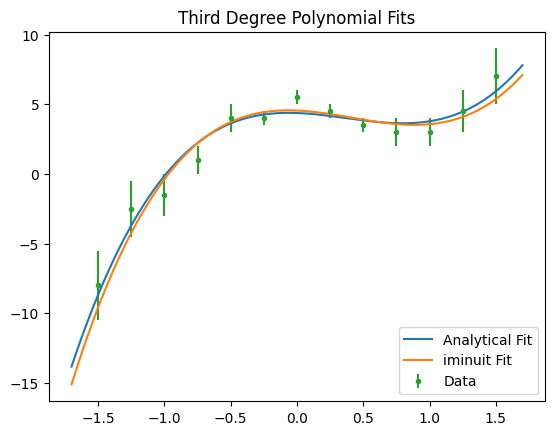

In [8]:
# read out and reformat the parameters and associated values to define the cubic_fit
params_minuit = list(m.values)
params_minuit_error = list(m.errors)
params_minuit_cov = np.asarray(m.covariance)
cubic_fit = Polynomial(params_minuit)

print_params(params_minuit, params_minuit_error, 6)
print('===== Covariance Matrix =====\n', params_minuit_cov, '\n')
print(cubic_fit)

# plot analytic and iminuit least squares fits on the same axes
plt.errorbar(x, y, yerr = sigma_y, linestyle='', marker='.', label = 'Data', color = 'tab:green')
plot_fitcurve_with_errorband(x, y, sigma_y, Polynomial(params), params_cov*0, 'Analytical Fit', True)
plot_fitcurve_with_errorband(x, y, sigma_y, cubic_fit, params_minuit_cov, 'iminuit Fit', True)
plt.title('Third Degree Polynomial Fits');

### Straight Line Fit
e) Plot the data with a straight-line fit. Determine the $p$-value for this straight-line fit. Is this an acceptable description of the data?

We reuse our functions to perform the same least squares regression fit with a polynomial with only two parameters (a linear model).
This time we have $11$ degrees of freedom because there are $2$ fewer fit parameters.

Again we read out the parameters and graph the model alongside the data and a $1\sigma$ error band.

Lastly we check the $\chi^2_{\mathrm{obs}}$ statistic and the $p$-value to see if the model is valid:
$$ \chi^2_{\mathrm{obs}} = 56.6 \\
p = 3.88 \times 10^{-8} $$

As we can also see on the $\chi^2$-distribution graph, the obtained $\chi^2_{\mathrm{obs}}$ statistic is extremely large compared to the bulk of the distribution. There is no surprise that this causes the probability of obtaining a result at least this large is very small. The $p$ value is most definitely under the significance level of $0.05$, leading to us *rejecting* the null hypothesis (that this model reflects the distribution which produced the data).

Therefore, this model is **not** an acceptable description of the data. It most likely comes from a different (nonlinear) distribution.

In [9]:
# redo iminuit minimisation of residuals function, but with only two parameters -> linear fit
l = Minuit(chi_square_for_params, *[1, 1])
l.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 56.64                      │              Nfcn = 31               │
│ EDM = 5.96e-24 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │   3.64    │   0.22    │            │            │         │         │       │
│ 1 │ x1   │    1.5    │    0.4    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────┐
│    │     x0     x1 │
├────┼───────────────┤
│ x0 │ 0.0485  -0.02 │
│ x1 │  -0.02  0.165 │
└────┴───────────────┘

===== Fit Parameters =====
theta_0:  3.641676 ± 0.220258
theta_1:  1.522123 ± 0.406485

3.642 + 1.522*x^1


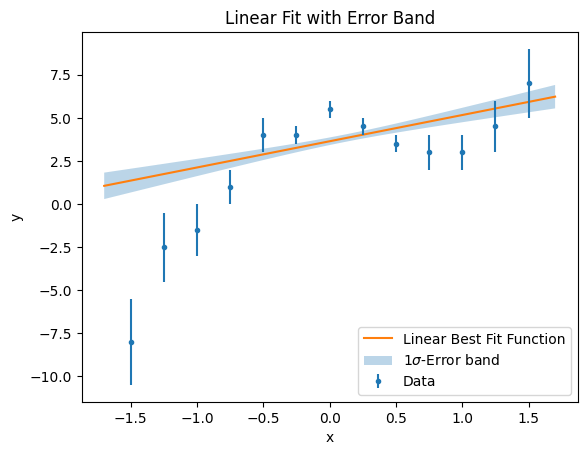

In [10]:
# read out and reformat the parameters and associated values to define the linear_fit
params = list(l.values)
params_error = list(l.errors)
linear_fit = Polynomial(params)

print_params(params, params_error, 6)
print()
print(linear_fit)

plot_fitcurve_with_errorband(
    x, y, sigma_y,
    linear_fit, np.asarray(l.covariance), 'Linear Best Fit Function'
    )
plt.title('Linear Fit with Error Band');

degrees_of_freedom = 11
chi2_obs = 56.63712
p-value = 3.8805e-08


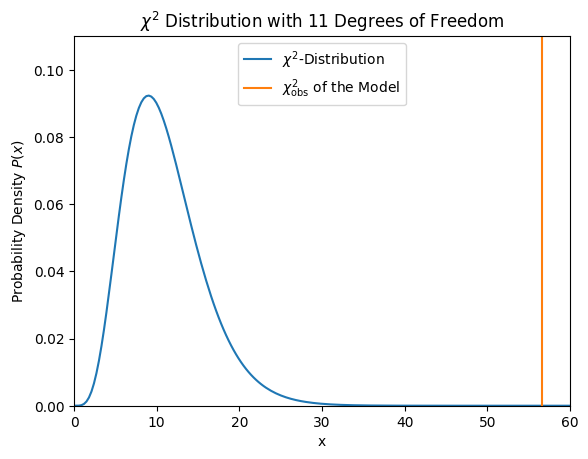

In [11]:
degrees_of_freedom = len(x) - len(params)
chi2_obs = chi_square_for_params(*params)
GOF_analysis(chi2_obs, degrees_of_freedom, ((0,60), (0,0.11)), p_sig_figs=12)

### $p$-Value
f) How does the $p$-value for a straight-line fit change if the error bars are twice as high in this example? Would you say the fit is describing the data well in this case?

To calculate this we simply redefine the function which calculates the $\chi^2$ statistic of our dataset. It now uses errors which are twice the size of the original ones. Doing the identical goodness of fit analysis shows that this gives the following test statistics:
$$ \chi^2_{\mathrm{obs}} = 14.2 \\
p = 0.224 $$

Obviously the degrees of freedom ($= 11$) do not change, as we have not changed our model or its number of parameters.

The $p$-value is now once again above a significance level of $0.05$, meaning this test fails to reject the null hypothesis, which is that the data did come from a linear distribution with the calculated parameters.

However, after graphing the linear fit again with new error bars, a visual inspection already causes some doubts that the model is valid. Analyzing which residuals contribute most to the $\chi^2$ statistic would be very insightful. This would show (as seen in the graph) that the data is not uniformly distributed around our best fit linear model. Instead, the model consistently overestimates $y$ when $x$ is small and it consistently underestimates $y$ when $x$ is large.

While the $p$-value hypothesis test would indicate that the fit is good in this case, the other considerations cause us to strongly doubt the validity of the linear model.

degrees_of_freedom = 11
chi2_obs = 14.15928
p-value = 0.2243


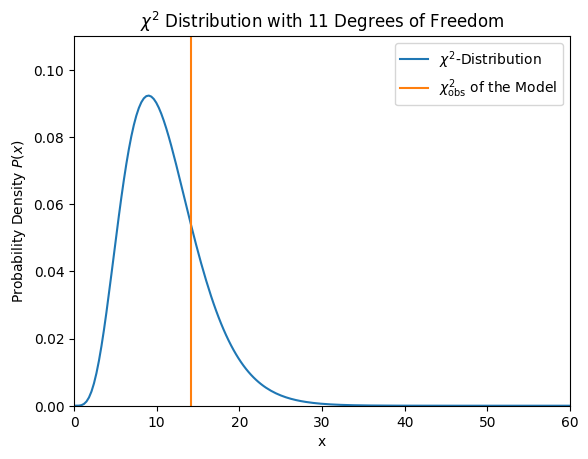

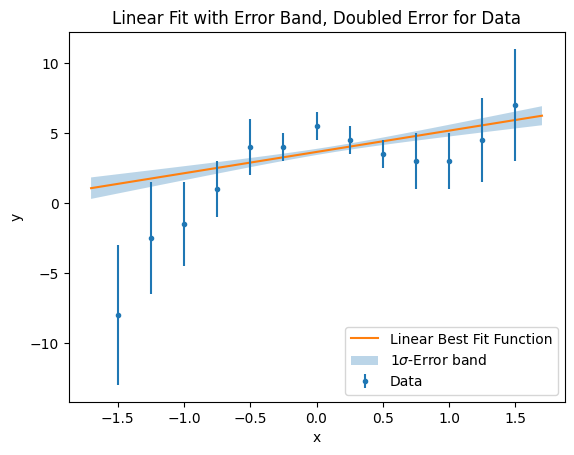

In [12]:
# define a new chi2 test statistic function with doubled errors
def chi_square_for_params_double_sigma(*args):
    fitcurve = Polynomial([*args])
    data2 = fitcurve.eval(x)
    return sum_square_residuals(y, data2, sigma_y * 2)

# redo the goodness of fit tests using the new function
degrees_of_freedom = len(x) - len(params)
chi2_obs = chi_square_for_params_double_sigma(*params)    # different chi2 function
GOF_analysis(chi2_obs, degrees_of_freedom, ((0,60), (0,0.11)), p_sig_figs=5)

plt.show()

# for completeness plot fitcurve again to see error bars doubled
plot_fitcurve_with_errorband(
    x, y, sigma_y * 2,
    linear_fit, np.asarray(l.covariance), 'Linear Best Fit Function'
    )
plt.title('Linear Fit with Error Band, Doubled Error for Data');